# Objective 2: Characterising features of human vs AI text

Now have dataset and piplines for surface, syntactic and semantic features. Have run the training data through these pipelines to extact three feature sets. Now we can look at objective 2 - comparing  / characterising the differences between human and AI generated text with regards to surface, syntactic and semantic features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests

Feature sets were extacted in part for training classifiers later and label / author data was not included in the feature selection, however, texts were processed in order on each occasion with no shuffling so we can re-extract the autor / label data for y_train.

In [2]:
# load up training data
train_df = pd.read_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\train_dataset_master.csv"
)

NB: train set has features 'label' and 'author' where 0 = human and 1 = AI generated.

In [3]:
y_train = train_df["label"].reset_index(drop = True)
print(y_train.shape)
print(y_train.value_counts())

(3199,)
label
1    1600
0    1599
Name: count, dtype: int64


As expected. We had 4000 (2000 each from human and AI) pieces of text, which became an 80/20% train/test split, then finally at the very end of extracting semantic features noted one text which was a BBC News article in Welsh that had not been detected initially and so was removed, resulting in a train set of 3199. Now need to load up feature data.

In [4]:
# load up feature data
surface_data = pd.read_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\X_train_surface.csv"
)
syntactic_data = pd.read_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\X_train_syntactic.csv"
)
semantic_data = pd.read_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\X_train_semantic.csv"
)

In [5]:
print(surface_data.shape)
print(syntactic_data.shape)
print(semantic_data.shape)

(3199, 96)
(3199, 96)
(3199, 7)


All matching length.

I now want a function to extract and compare features between human and AI authored.

In [6]:
# funtion to compare features between human and ai for the three feature groups - surface / syntactic / semantic

# x is dataframe of feature extraction
# y is the label series of human / AI
# feature group explains surface / syntactic etc 
# and is just name passed through for logging info
def compare_features(x, y, feature_group):

    # initialise empty list to store results
    results = []

    # create true / false human / ai rows
    human = y == 0
    ai = y == 1

    # loop through feature columns in the dataset being passed through
    # more appropriate than rows so can calculate for each column/feature one at a time
    for feature in x.columns:

        # get data in rows where author was human
        human_data = x.loc[human, feature]
        # get data in rows where author was ai
        ai_data = x.loc[ai, feature]

        # get mann-whitney u p-value
        _, p_value = mannwhitneyu(
            human_data, 
            ai_data, 
            alternative = "two-sided"
        )

        # calculate roc-auc
        auc = roc_auc_score(y, x[feature])
        # auc calcualtes 0.5 no discrimination and 0 and 1 max 
        # for the sake of plotting and readability this just takes values
        # from 0 - 0.4 and does 1-answer so that all values are aligned
        # on discriminatory strength alone
        auc_strength = max(auc, 1 - auc)

        # add all data into results list for the current feature
        results.append({
            "feature_group" : feature_group,
            "feature" : feature,
            "human_median" : human_data.median(),
            "human_mean" : human_data.mean(),
            "ai_median" : ai_data.median(),
            "ai_mean" : ai_data.mean(),
            "ROC_AUC" : auc,
            "AUC_strength" : auc_strength,
            "p_value" : p_value
        })

    # convert to DF
    results = pd.DataFrame(results)
    # FDR must be applied to all p_values once stored, hence outisde loop
    # stored as new variable p_value_adjusted
    results["p_value_adjusted"] = multipletests(
        results["p_value"], 
        method = "fdr_bh"
    )[1]

    return results

Can now run the function for all three feature sets.

In [7]:
surface_results = compare_features(surface_data, y_train, "Surface")
syntactic_results = compare_features(syntactic_data, y_train, "Syntactic")
semantic_results = compare_features(semantic_data, y_train, "Semantic")

In [8]:
surface_results
# syntactic_results
# semantic_results

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
0,Surface,word_count,390.000000,387.099437,397.000000,396.005625,0.600245,0.600245,9.243858e-23,2.164416e-22
1,Surface,character_count,2286.000000,2286.757974,2427.000000,2455.260625,0.660163,0.660163,1.833587e-55,7.653232e-55
2,Surface,sentence_count,20.000000,20.724828,20.000000,20.865625,0.543779,0.543779,1.683252e-05,2.411823e-05
3,Surface,mean_word_length,4.492401,4.521811,4.833765,4.967978,0.705464,0.705464,4.459257e-90,3.057776e-89
4,Surface,std_word_length,2.401868,2.401795,2.578308,2.568542,0.635297,0.635297,4.381253e-40,1.450346e-39
...,...,...,...,...,...,...,...,...,...,...
91,Surface,func_ratio_who,0.000000,0.002264,0.000000,0.001746,0.461163,0.538837,3.574229e-05,4.901800e-05
92,Surface,func_ratio_will,0.000000,0.002400,0.000000,0.001733,0.448390,0.551610,5.947619e-09,1.038130e-08
93,Surface,func_ratio_with,0.007194,0.007524,0.007109,0.006867,0.475224,0.524776,1.520937e-02,1.848227e-02
94,Surface,func_ratio_would,0.002381,0.002996,0.002358,0.002951,0.495757,0.504243,6.592643e-01,6.732912e-01


Now combine to one DF.

In [9]:
feature_results = pd.concat(
    [
        surface_results,
        syntactic_results,
        semantic_results,
    ], ignore_index = True
)

In [10]:
feature_results

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
0,Surface,word_count,390.000000,387.099437,397.000000,396.005625,0.600245,0.600245,9.243858e-23,2.164416e-22
1,Surface,character_count,2286.000000,2286.757974,2427.000000,2455.260625,0.660163,0.660163,1.833587e-55,7.653232e-55
2,Surface,sentence_count,20.000000,20.724828,20.000000,20.865625,0.543779,0.543779,1.683252e-05,2.411823e-05
3,Surface,mean_word_length,4.492401,4.521811,4.833765,4.967978,0.705464,0.705464,4.459257e-90,3.057776e-89
4,Surface,std_word_length,2.401868,2.401795,2.578308,2.568542,0.635297,0.635297,4.381253e-40,1.450346e-39
...,...,...,...,...,...,...,...,...,...,...
194,Semantic,hyponym_density,0.649123,0.649224,0.684479,0.672998,0.602310,0.602310,1.230873e-23,4.308055e-23
195,Semantic,mean_adj_sent_similarity,0.318847,0.328122,0.300512,0.305081,0.414587,0.585413,5.954169e-17,1.389306e-16
196,Semantic,std_adj_sent_similarity,0.146020,0.149862,0.128626,0.129540,0.321005,0.678995,8.107156e-69,5.675010e-68
197,Semantic,mean_sent_doc_similarity,0.546542,0.550350,0.560889,0.556264,0.537671,0.537671,2.244155e-04,2.618181e-04


Expected 96, 96 and 7 = 199 features so all good.

Can now look at all seperate featues and rank by AUC_strength, that is, the strength of the discimination between them. ROC_AUC gives value from 0 - 1 where 0.5 is no discrimination, i.e. random chance. This goes to a max at 0 and 1 which account for different directions of discrimination. The AUC_strength excludes direction and makes it a 0.5 - 1 scale whereby 0.5 is no discrimination and 1 is perfect discrimination. 

In [11]:
best_features = feature_results.sort_values(
    "AUC_strength",
    ascending = False
)

best_features.head(20)

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
11,Surface,mtld,83.350515,84.876052,145.995872,150.891060,0.950266,0.950266,0.000000e+00,0.000000e+00
7,Surface,root_ttr,10.071978,9.999202,11.747654,11.721610,0.934122,0.934122,0.000000e+00,0.000000e+00
8,Surface,hapax_l_ratio,0.356098,0.353988,0.451175,0.448068,0.917411,0.917411,0.000000e+00,0.000000e+00
22,Surface,lower_ratio,0.758447,0.756193,0.796765,0.796546,0.896772,0.896772,0.000000e+00,0.000000e+00
20,Surface,alpha_ratio,0.784992,0.784359,0.811485,0.811228,0.845782,0.845782,1.907292e-251,3.662000e-250
21,Surface,upper_ratio,0.025759,0.028119,0.014174,0.014682,0.154317,0.845683,2.646726e-251,4.234762e-250
132,Syntactic,pos_bigram_NOUN_VERB,0.017621,0.019547,0.037500,0.037826,0.831029,0.831029,1.258836e-230,1.208482e-228
6,Surface,std_sentence_length,9.349233,10.570189,6.704573,6.886434,0.188690,0.811310,3.279019e-204,4.496940e-203
109,Syntactic,pos_ratio_NOUN,0.164990,0.166168,0.201784,0.217507,0.793771,0.793771,4.472663e-182,2.146878e-180
25,Surface,punct_ratio,0.030132,0.032501,0.022071,0.023880,0.226858,0.773142,1.109979e-157,1.331974e-156


Some very high discrimination there which is good, will tidy up for report.

In [12]:
best_features.to_csv(
    r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\objective_2_best_features.csv",
    index = False
)

In [2]:
best_features = pd.read_csv(r"C:\Users\Jamie\Desktop\DSM500 Final Project\Code\Final datasets v2 last update\objective_2_best_features.csv")

In [3]:
best_features.head(20)

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
0,Surface,mtld,83.350515,84.876052,145.995872,150.891060,0.950266,0.950266,0.000000e+00,0.000000e+00
1,Surface,root_ttr,10.071978,9.999202,11.747654,11.721610,0.934122,0.934122,0.000000e+00,0.000000e+00
2,Surface,hapax_l_ratio,0.356098,0.353988,0.451175,0.448068,0.917411,0.917411,0.000000e+00,0.000000e+00
3,Surface,lower_ratio,0.758447,0.756193,0.796765,0.796546,0.896772,0.896772,0.000000e+00,0.000000e+00
4,Surface,alpha_ratio,0.784992,0.784359,0.811485,0.811228,0.845782,0.845782,1.907292e-251,3.662000e-250
5,Surface,upper_ratio,0.025759,0.028119,0.014174,0.014682,0.154317,0.845683,2.646726e-251,4.234762e-250
6,Syntactic,pos_bigram_NOUN_VERB,0.017621,0.019547,0.037500,0.037826,0.831029,0.831029,1.258836e-230,1.208482e-228
7,Surface,std_sentence_length,9.349233,10.570189,6.704573,6.886434,0.188690,0.811310,3.279019e-204,4.496940e-203
8,Syntactic,pos_ratio_NOUN,0.164990,0.166168,0.201784,0.217507,0.793771,0.793771,4.472663e-182,2.146878e-180
9,Surface,punct_ratio,0.030132,0.032501,0.022071,0.023880,0.226858,0.773142,1.109979e-157,1.331974e-156


____

Clealy surface features trump others when differentiating between a human and AI author. But lets get some stats to compare surface / syntactic / semantic.

In [16]:
# group by feature group - surface etc
summary = (
    best_features
    .groupby("feature_group")
    # get num of features in each group
    .agg(number_of_features = ("feature", "count"),
         # ... and significant features where fdr < 0.05, i.e. disriminative
         significant_features = (
             "p_value_adjusted",
             lambda x: (x < 0.05).sum()
         ),
         # then get mean and max strength in each group
         mean_discrimination = ("AUC_strength", "mean"),
         max_discrimination = ("AUC_strength", "max")
    )
    .reset_index()
)

summary    

,feature_group,number_of_features,significant_features,mean_discrimination,max_discrimination
0,Semantic,7,6,0.573144,0.678995
1,Surface,96,84,0.602619,0.950266
2,Syntactic,96,82,0.609456,0.831029


___

Lets check top features from each category.

In [18]:
# get 5 strongest discriminating features from each category
best_surface = (surface_results.sort_values("AUC_strength", ascending = False).head(5))
best_syntactic = (syntactic_results.sort_values("AUC_strength", ascending = False).head(5))
best_semantic = (semantic_results.sort_values("AUC_strength", ascending = False).head(5))

In [19]:
best_surface

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
11,Surface,mtld,83.350515,84.876052,145.995872,150.891060,0.950266,0.950266,0.000000e+00,0.000000e+00
7,Surface,root_ttr,10.071978,9.999202,11.747654,11.721610,0.934122,0.934122,0.000000e+00,0.000000e+00
8,Surface,hapax_l_ratio,0.356098,0.353988,0.451175,0.448068,0.917411,0.917411,0.000000e+00,0.000000e+00
22,Surface,lower_ratio,0.758447,0.756193,0.796765,0.796546,0.896772,0.896772,0.000000e+00,0.000000e+00
20,Surface,alpha_ratio,0.784992,0.784359,0.811485,0.811228,0.845782,0.845782,1.907292e-251,3.662000e-250


In [20]:
best_syntactic

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
36,Syntactic,pos_bigram_NOUN_VERB,0.017621,0.019547,0.037500,0.037826,0.831029,0.831029,1.258836e-230,1.208482e-228
13,Syntactic,pos_ratio_NOUN,0.164990,0.166168,0.201784,0.217507,0.793771,0.793771,4.472663e-182,2.146878e-180
21,Syntactic,pos_ratio_VERB,0.108911,0.107502,0.125786,0.126909,0.759612,0.759612,1.214019e-142,3.884860e-141
34,Syntactic,pos_bigram_NOUN_AUX,0.019737,0.021399,0.033626,0.035327,0.751155,0.751155,1.249724e-133,2.999338e-132
48,Syntactic,pos_bigram_PUNCT_PRON,0.019231,0.021672,0.009202,0.011183,0.258829,0.741171,2.082995e-123,3.999351e-122


In [21]:
best_semantic

,feature_group,feature,human_median,human_mean,ai_median,ai_mean,ROC_AUC,AUC_strength,p_value,p_value_adjusted
4,Semantic,std_adj_sent_similarity,0.146020,0.149862,0.128626,0.129540,0.321005,0.678995,8.107156e-69,5.675010e-68
2,Semantic,hyponym_density,0.649123,0.649224,0.684479,0.672998,0.602310,0.602310,1.230873e-23,4.308055e-23
3,Semantic,mean_adj_sent_similarity,0.318847,0.328122,0.300512,0.305081,0.414587,0.585413,5.954169e-17,1.389306e-16
1,Semantic,hypernym_density,0.693122,0.693151,0.717131,0.708667,0.568335,0.568335,2.181391e-11,3.817434e-11
6,Semantic,mean_embedding_variance,0.001826,0.001804,0.001785,0.001790,0.462329,0.537671,2.243986e-04,2.618181e-04


_____

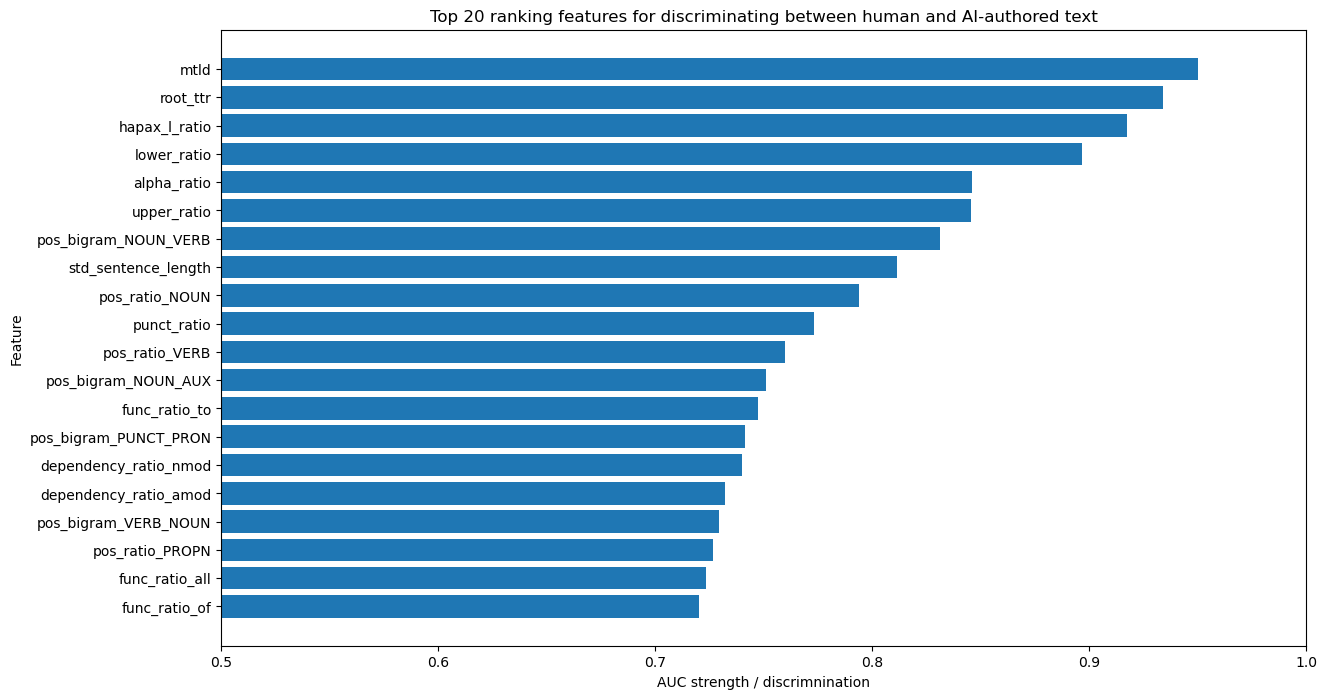

In [22]:
# plot top 20 features based on AUC strength
best_plot = (
    feature_results.sort_values("AUC_strength", ascending = False)
    .head(20)
    .sort_values("AUC_strength")
)

plt.figure(figsize = (14, 8))
plt.barh(
    best_plot["feature"],
    best_plot["AUC_strength"],
)

plt.xlabel("AUC strength / discrimnination")
plt.ylabel("Feature")
plt.title("Top 20 ranking features for discriminating between human and AI-authored text")
plt.xlim(0.5, 1)

plt.show()

Individual plots for key variables.

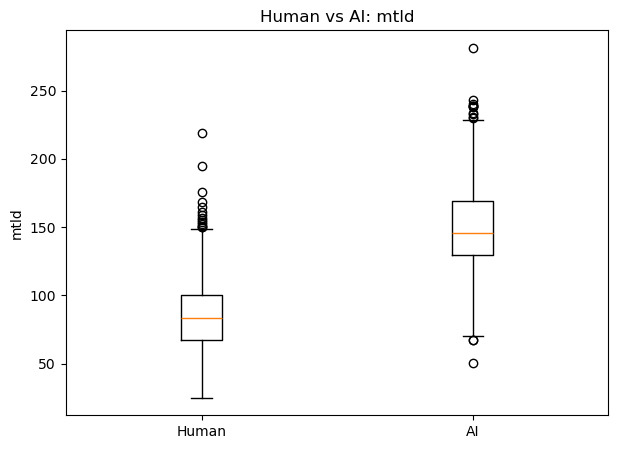

In [23]:
# specify feature
feature = "mtld"

plt.figure(figsize = (7, 5))

# boxplot, selecting feature values  for human and AI seperately
plt.boxplot(
    [
        surface_data.loc[y_train == 0, feature],
        surface_data.loc[y_train == 1, feature]
    ],
    tick_labels = ["Human", "AI"]
)

plt.ylabel(feature)
plt.title(f"Human vs AI: {feature}")
plt.show()

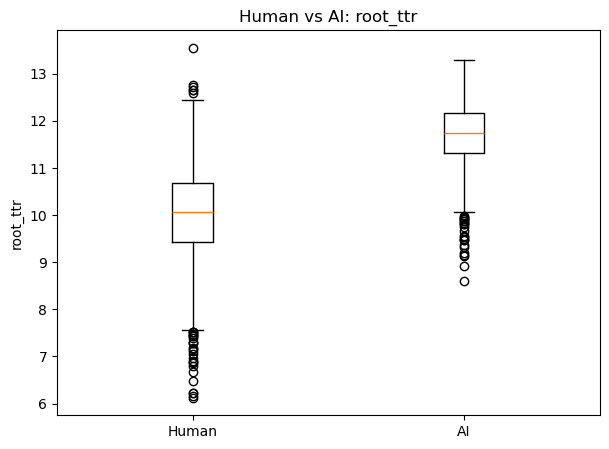

In [25]:
# specify feature
feature = "root_ttr"

plt.figure(figsize = (7, 5))

# boxplot, selecting feature values  for human and AI seperately
plt.boxplot(
    [
        surface_data.loc[y_train == 0, feature],
        surface_data.loc[y_train == 1, feature]
    ],
    tick_labels = ["Human", "AI"]
)

plt.ylabel(feature)
plt.title(f"Human vs AI: {feature}")
plt.show()

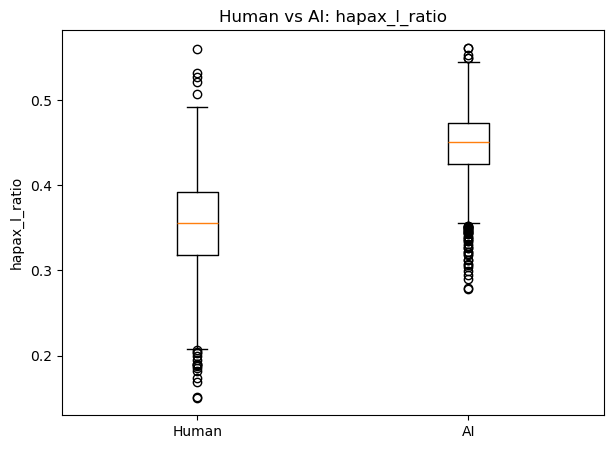

In [26]:
# specify feature
feature = "hapax_l_ratio"

plt.figure(figsize = (7, 5))

# boxplot, selecting feature values  for human and AI seperately
plt.boxplot(
    [
        surface_data.loc[y_train == 0, feature],
        surface_data.loc[y_train == 1, feature]
    ],
    tick_labels = ["Human", "AI"]
)

plt.ylabel(feature)
plt.title(f"Human vs AI: {feature}")
plt.show()

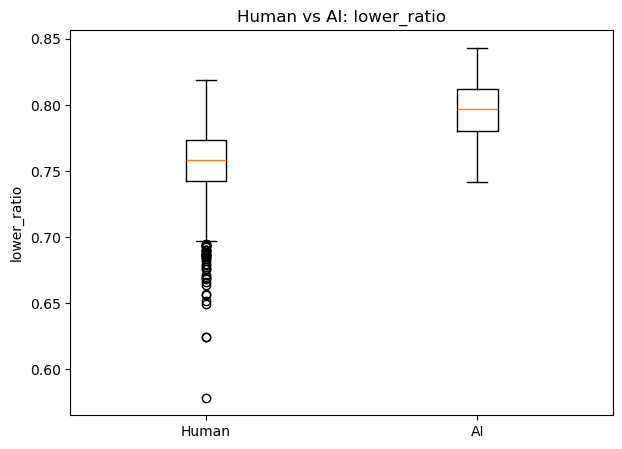

In [27]:
# specify feature
feature = "lower_ratio"

plt.figure(figsize = (7, 5))

# boxplot, selecting feature values  for human and AI seperately
plt.boxplot(
    [
        surface_data.loc[y_train == 0, feature],
        surface_data.loc[y_train == 1, feature]
    ],
    tick_labels = ["Human", "AI"]
)

plt.ylabel(feature)
plt.title(f"Human vs AI: {feature}")
plt.show()

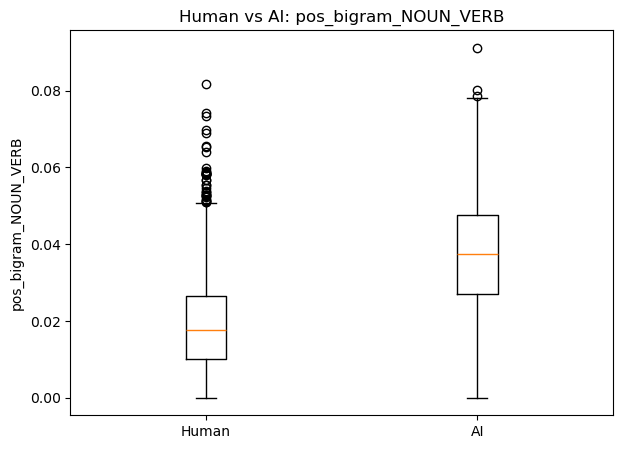

In [29]:
# specify feature
feature = "pos_bigram_NOUN_VERB"

plt.figure(figsize = (7, 5))

# boxplot, selecting feature values  for human and AI seperately
plt.boxplot(
    [
        syntactic_data.loc[y_train == 0, feature],
        syntactic_data.loc[y_train == 1, feature]
    ],
    tick_labels = ["Human", "AI"]
)

plt.ylabel(feature)
plt.title(f"Human vs AI: {feature}")
plt.show()